# Introduction to Computer Vision: Plant Seedlings Classification

## Problem Statement

### Context

In recent times, the field of agriculture has been in urgent need of modernizing, since the amount of manual work people need to put in to check if plants are growing correctly is still highly extensive. Despite several advances in agricultural technology, people working in the agricultural industry still need to have the ability to sort and recognize different plants and weeds, which takes a lot of time and effort in the long term. The potential is ripe for this trillion-dollar industry to be greatly impacted by technological innovations that cut down on the requirement for manual labor, and this is where Artificial Intelligence can actually benefit the workers in this field, as **the time and energy required to identify plant seedlings will be greatly shortened by the use of AI and Deep Learning.** The ability to do so far more efficiently and even more effectively than experienced manual labor, could lead to better crop yields, the freeing up of human inolvement for higher-order agricultural decision making, and in the long term will result in more sustainable environmental practices in agriculture as well.


### Objective

The aim of this project is to Build a Convolutional Neural Netowrk to classify plant seedlings into their respective categories.

### Data Dictionary

The Aarhus University Signal Processing group, in collaboration with the University of Southern Denmark, has recently released a dataset containing **images of unique plants belonging to 12 different species.**

- The dataset can be download from Olympus.
- The data file names are:
    - images.npy
    - Labels.csv
- Due to the large volume of data, the images were converted to the images.npy file and the labels are also put into Labels.csv, so that you can work on the data/project seamlessly without having to worry about the high data volume.

- The goal of the project is to create a classifier capable of determining a plant's species from an image.

**List of Species**

- Black-grass
- Charlock
- Cleavers
- Common Chickweed
- Common Wheat
- Fat Hen
- Loose Silky-bent
- Maize
- Scentless Mayweed
- Shepherds Purse
- Small-flowered Cranesbill
- Sugar beet

### **Note: Please use GPU runtime on Google Colab to execute the code faster.**

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
# !pip install tensorflow==2.15.0 scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 opencv-python==4.8.0.76 -q --user

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
#!pip install tensorflow==2.13.0 scikit-learn==1.2.2 seaborn==0.11.1 matplotlib==3.3.4 numpy==1.24.3 pandas==1.5.2 opencv-python==4.8.0.76 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [2]:
import os
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2                                                                                       # Importing openCV for image processing
import seaborn as sns                                                                            # Importing seaborn to plot graphs


# Tensorflow modules
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix                                                     # Importing confusion_matrix to plot the confusion matrix
from sklearn.preprocessing import LabelBinarizer
# Display images using OpenCV
from google.colab.patches import cv2_imshow                                                      # Importing cv2_imshow from google.patches to display images
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend
from keras.callbacks import ReduceLROnPlateau
import random
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Loading the dataset

In [ ]:
# Uncomment and run the below code if you are using google colab
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load the image file of dataset
images = np.load('/content/drive/MyDrive/mks/images.npy')

# Load the labels file of dataset
labels = pd.read_csv('/content/drive/MyDrive/mks/Labels.csv')

In [5]:
labels.head()

,Label
0,Small-flowered Cranesbill
1,Small-flowered Cranesbill
2,Small-flowered Cranesbill
3,Small-flowered Cranesbill
4,Small-flowered Cranesbill


## Data Overview

### Understand the shape of the dataset

In [6]:
print(images.shape)
print(labels.shape)

(4750, 128, 128, 3)
(4750, 1)


There are 4750 RGB images of shape 128 x 128 X 3, each image having 3 channels.

In [7]:
labels['Label'].unique()

array(['Small-flowered Cranesbill', 'Fat Hen', 'Shepherds Purse',
       'Common wheat', 'Common Chickweed', 'Charlock', 'Cleavers',
       'Scentless Mayweed', 'Sugar beet', 'Maize', 'Black-grass',
       'Loose Silky-bent'], dtype=object)

In [8]:
labels['Label'].nunique()

12

Total Number of Plant Categories are 12 which means our output predictions are 12

## Exploratory Data Analysis

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you understand the data better.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

1. How are these different category plant images different from each other?
2. Is the dataset provided an imbalance? (Check with using bar plots)

### Plant Categories Distribution to check data imbalance

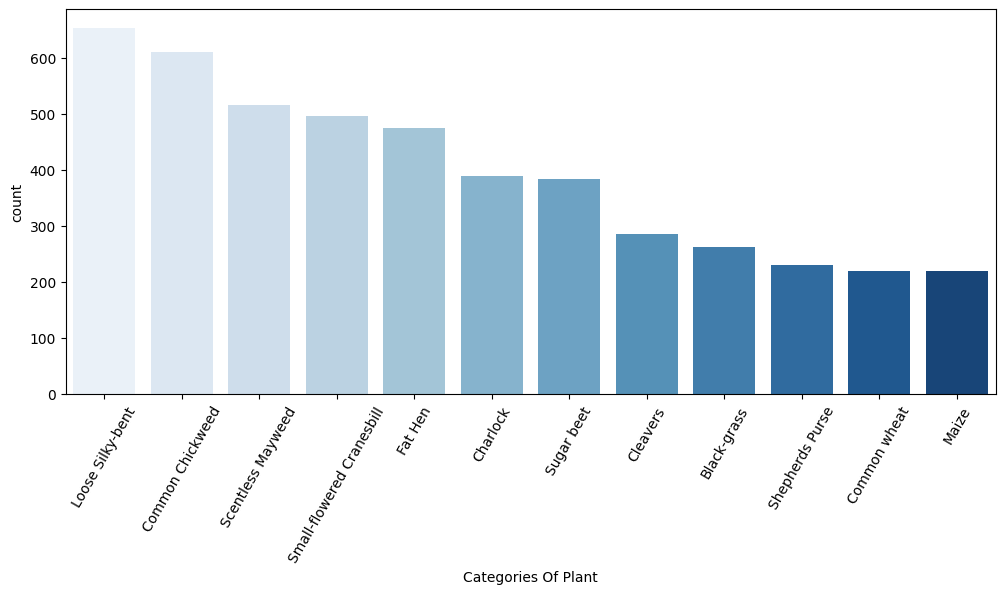

In [9]:
plt.rcParams["figure.figsize"] = (12,5)
sns.countplot(x=labels.iloc[:,-1],order = labels['Label'].value_counts().index, palette='Blues')
plt.xlabel('Categories Of Plant')
plt.xticks(rotation=60)
plt.show()

Loose Silky-bent Plant samples are more in the dataset compared & Maize has least number of plant samples

### Plotting random images from each of the class

In [10]:
def plot_images(images,labels):
  num_classes=10                                                                  # Number of Classes
  categories=np.unique(labels)
  keys=dict(labels['Label'])                                                      # Obtaing the unique classes from y_train
  rows = 3                                                                        # Defining number of rows=3
  cols = 4                                                                        # Defining number of columns=4
  fig = plt.figure(figsize=(10, 8))                                               # Defining the figure size to 10x8
  for i in range(cols):
      for j in range(rows):
          random_index = np.random.randint(0, len(labels))                        # Generating random indices from the data and plotting the images
          ax = fig.add_subplot(rows, cols, i * rows + j + 1)                      # Adding subplots with 3 rows and 4 columns
          ax.imshow(images[random_index, :])                                      # Plotting the image
          ax.set_title(keys[random_index])
  plt.show()

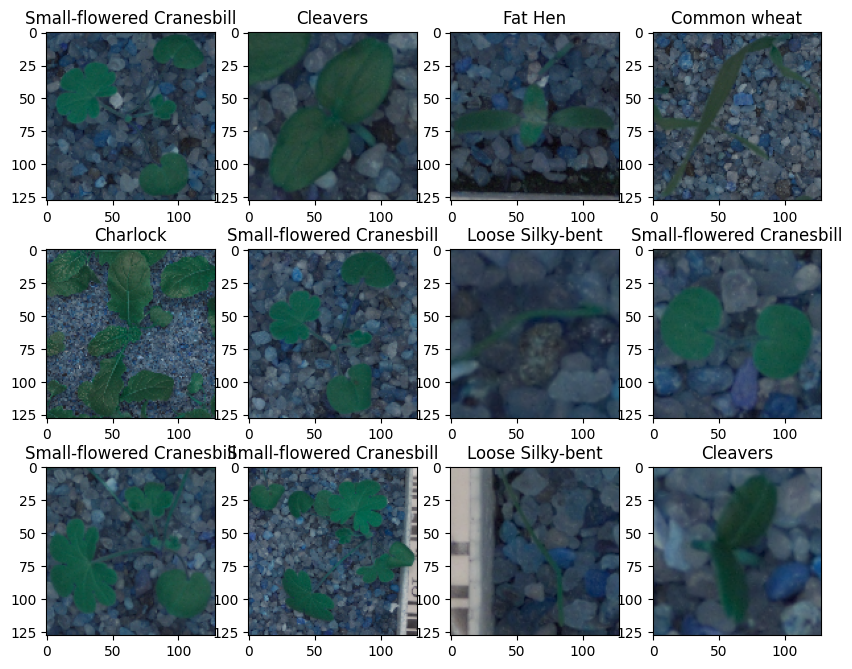

In [11]:
plot_images(images,labels)

## Data Pre-Processing

### Converting BGR images to RGB images

In [12]:
# Converting the images from BGR to RGB using cvtColor function of OpenCV
for i in range(len(images)):
  images[i] = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)

### Resize the images

**As the size of the images is large, it may be computationally expensive to train on these larger images; therefore, it is preferable to reduce the image size from 128 to 64.**



In [13]:
images_decreased=[]
height = 64
width = 64
dimensions = (width, height)
for i in range(len(images)):
  images_decreased.append( cv2.resize(images[i], dimensions, interpolation=cv2.INTER_LINEAR))

**Image before resizing**

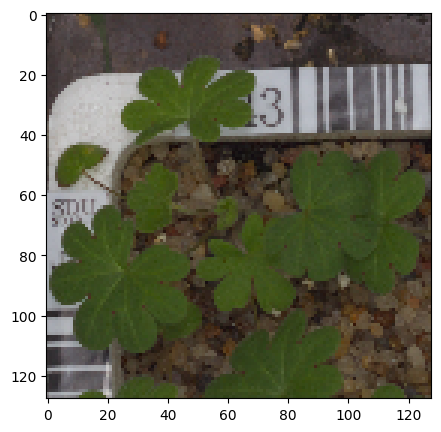

In [14]:
plt.imshow(images[3])

**Image after resizing**

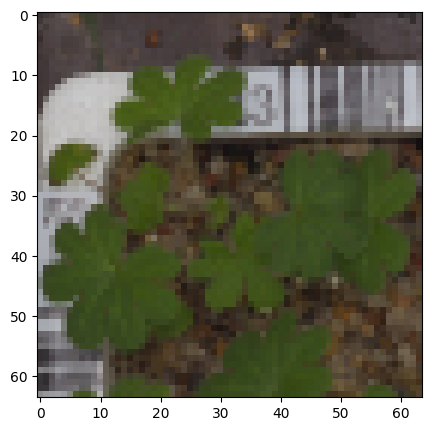

In [15]:
plt.imshow(images_decreased[3])

### Data Preparation for Modeling

- Before you proceed to build a model, you need to split the data into train, test, and validation to be able to evaluate the model that you build on the train data
- You'll have to encode categorical features and scale the pixel values.
- You will build a model using the train data and then check its performance

**Split the dataset**


**As we have less images in our dataset, we will only use 10% of our data for testing, 10% of our data for validation and 80% of our data for training.**


**We are using the train_test_split() function from scikit-learn. Here, we split the dataset into three parts, train,test and validation**

In [16]:
from sklearn.model_selection import train_test_split
X_temp, X_test, y_temp, y_test = train_test_split(np.array(images_decreased),labels , test_size=0.1, random_state=42,stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(X_temp,y_temp , test_size=0.1, random_state=42,stratify=y_temp)

In [17]:
# Let's check the shape of the train, test & validation data
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)
print(X_test.shape,y_test.shape)

(3847, 64, 64, 3) (3847, 1)
(428, 64, 64, 3) (428, 1)
(475, 64, 64, 3) (475, 1)


X_train has 3847 plant images

X_val has 428 plant images

X_test has 475 plant images

Plan images are in 64X64 shape with color channel

### Encode the target labels

**Convert labels from names to one hot vectors**

In [18]:
# Convert labels from names to one hot vectors.
# We have already used encoding methods like onehotencoder and labelencoder earlier so now we will be using a new encoding method called labelBinarizer.
# Labelbinarizer works similar to onehotencoder

from sklearn.preprocessing import LabelBinarizer
enc = LabelBinarizer()
y_train_encoded = enc.fit_transform(y_train)
y_val_encoded=enc.transform(y_val)
y_test_encoded=enc.transform(y_test)

In [19]:
# Let's check shape of the train , validation & test  after encode
y_train_encoded.shape,y_val_encoded.shape,y_test_encoded.shape

((3847, 12), (428, 12), (475, 12))

### Data Normalization

**Since the image pixel values range from 0-255, our method of normalization here will be scaling - we shall divide all the pixel values by 255 to standardize the images to have values between 0-1.**

In [20]:
# Normalizing the image pixels
X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0

## Model Building

**Model Building - Convolutional Neural Network (CNN)
Let's create a CNN model sequentially, where we will be adding the layers one after another.**

**First, we need to clear the previous model's history from the session even if a single model can run multiple times on the same data.**

**In Keras, we need a special command to clear the model's history, otherwise the previous model history remains in the backend.**

**Also, let's fix the seed again after clearing the backend.**

**Let's set the seed for random number generators in Numpy, the Random library in Python, and in TensorFlow to be able to reproduce the same results every time we run the code.**

In [21]:
# Clearing backend
from tensorflow.keras import backend
backend.clear_session()

In [22]:
# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

**Now, let's build a CNN Model with the following 2 main parts -**

**The Feature Extraction layers which are comprised of convolutional and pooling layers.**

**The Fully Connected classification layers for prediction.**

In [23]:
# Intializing a sequential model
model1 = Sequential()

# Adding first conv layer with 64 filters and kernel size 3x3 , padding 'same' provides the output size same as the input size
# Input_shape denotes input image dimension of images
model1.add(Conv2D(64, (3, 3), activation='relu', padding="same", input_shape=(64, 64, 3)))

# Adding max pooling to reduce the size of output of first conv layer
model1.add(MaxPooling2D((2, 2), padding = 'same'))

# Creating two similar convolution and max-pooling layers activation = relu
model1.add(Conv2D(64, (3, 3), activation='relu', padding="same"))
model1.add(MaxPooling2D((2, 2), padding = 'same'))

model1.add(Conv2D(32, (3, 3), activation='relu', padding="same"))
model1.add(MaxPooling2D((2, 2), padding = 'same'))

# flattening the output of the conv layer after max pooling to make it ready for creating dense connections
model1.add(Flatten())

# Adding a fully connected dense layer with 16 neurons
model1.add(Dense(16, activation='relu'))
model1.add(Dropout(0.3))
# Adding the output layer with 12 neurons and activation functions as softmax since this is a multi-class classification problem
model1.add(Dense(12, activation='softmax'))

# Using Adam Optimizer
opt=Adam()
# Compile model
model1.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Generating the summary of the model
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │          32,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 12)                  │             204 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 90,172 (352.23 KB)

 Trainable params: 90,172 (352.23 KB)

 Non-trainable params: 0 (0.00 B)

**Fitting the model on the train data**

In [24]:
history_1 = model1.fit(
            X_train_normalized, y_train_encoded,
            epochs=30,
            validation_data=(X_val_normalized,y_val_encoded),
            batch_size=32,
            verbose=2
)

Epoch 1/30
121/121 - 58s - 478ms/step - accuracy: 0.1050 - loss: 2.4569 - val_accuracy: 0.2196 - val_loss: 2.4156
Epoch 2/30
121/121 - 49s - 404ms/step - accuracy: 0.2186 - loss: 2.3126 - val_accuracy: 0.3014 - val_loss: 2.0644
Epoch 3/30
121/121 - 83s - 690ms/step - accuracy: 0.2677 - loss: 2.0857 - val_accuracy: 0.3528 - val_loss: 1.8729
Epoch 4/30
121/121 - 80s - 662ms/step - accuracy: 0.3026 - loss: 1.9418 - val_accuracy: 0.4089 - val_loss: 1.7472
Epoch 5/30
121/121 - 88s - 724ms/step - accuracy: 0.3512 - loss: 1.8068 - val_accuracy: 0.4206 - val_loss: 1.6717
Epoch 6/30
121/121 - 49s - 406ms/step - accuracy: 0.3782 - loss: 1.7165 - val_accuracy: 0.5584 - val_loss: 1.4817
Epoch 7/30
121/121 - 48s - 400ms/step - accuracy: 0.4081 - loss: 1.6130 - val_accuracy: 0.5537 - val_loss: 1.3211
Epoch 8/30
121/121 - 82s - 675ms/step - accuracy: 0.4297 - loss: 1.5663 - val_accuracy: 0.5584 - val_loss: 1.2607
Epoch 9/30
121/121 - 82s - 680ms/step - accuracy: 0.4258 - loss: 1.5251 - val_accuracy: 

**Model Evaluation**

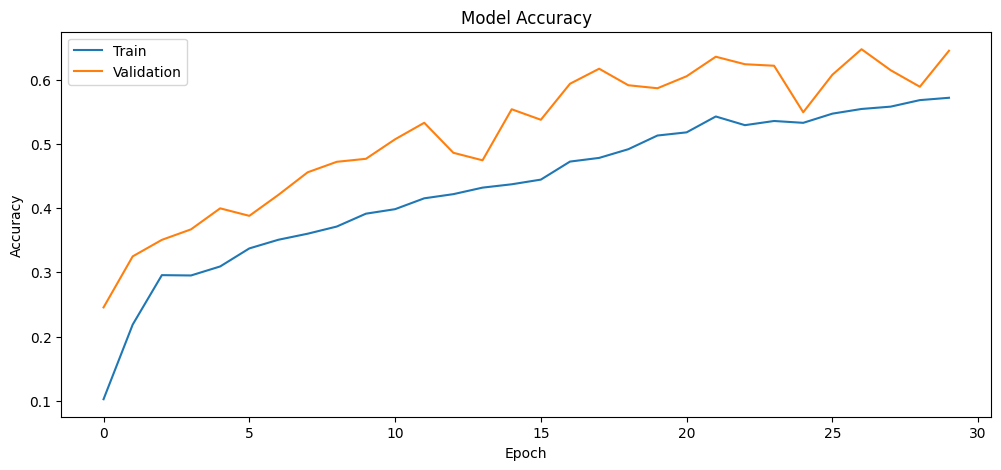

In [ ]:
plt.plot(history_1.history['accuracy'])
plt.plot(history_1.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

**Evaluate the model on test data**

In [ ]:
accuracy = model1.evaluate(X_test_normalized, y_test_encoded, verbose=2)

15/15 - 0s - 24ms/step - accuracy: 0.6463 - loss: 1.1245


**Generating the predictions using test data**

In [ ]:
# Here we would get the output as probablities for each category
y_pred=model1.predict(X_test_normalized)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [ ]:
y_pred

array([[1.5412266e-12, 2.0359235e-10, 1.5958299e-11, ..., 2.2972265e-02,
        6.5489578e-09, 2.2413293e-05],
       [5.6212144e-12, 2.1685787e-02, 1.3112677e-03, ..., 6.4579747e-03,
        9.4902003e-01, 1.6036576e-02],
       [6.6792412e-09, 2.7871647e-05, 1.2916949e-05, ..., 6.8342844e-05,
        9.9176496e-01, 7.8990757e-03],
       ...,
       [3.1385896e-01, 2.9288400e-14, 1.9455073e-09, ..., 1.1724922e-12,
        2.7557132e-10, 1.4293558e-05],
       [2.9489421e-04, 1.8690206e-04, 7.1313948e-04, ..., 7.7303424e-02,
        2.2405545e-04, 1.6313529e-01],
       [6.8287642e-09, 3.0230060e-03, 2.5295571e-04, ..., 4.9095407e-01,
        4.3154294e-03, 6.3894533e-02]], dtype=float32)

**Plotting the Confusion Matrix**

**The Confusion matrix is also defined as an inbuilt function in the TensorFlow module, so we can use that for evaluating the classification model.**

**The Confusion matrix expects categorical data as input. However, y_test_encoded is an encoded value, whereas y_pred has probabilities. So,we must retrieve the categorical values from the encoded values.**

**We will use the argmax() function to obtain the maximum value over each category on both y_test_encoded and y_pred and obtain their respective classes.**

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


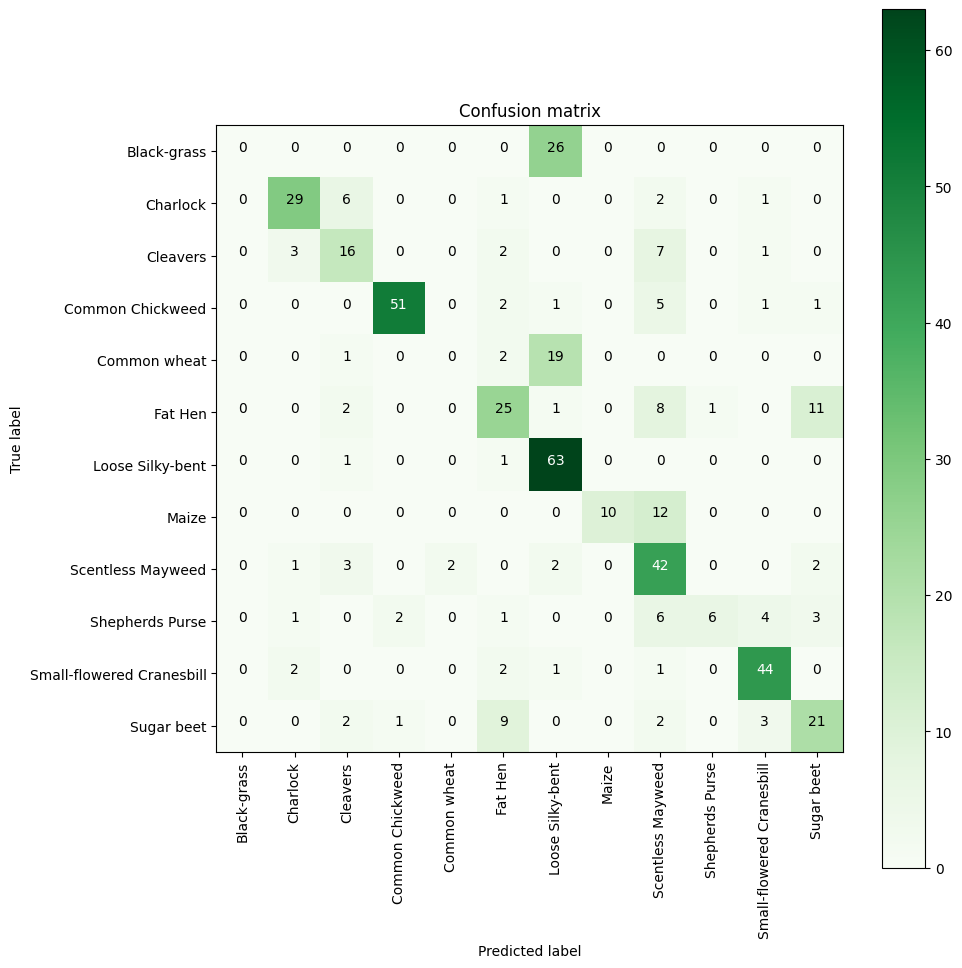

In [ ]:
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Greens):

    fig = plt.figure(figsize=(10,10))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Predict the values from the validation dataset
predY = model1.predict(X_test_normalized)
predYClasses = np.argmax(predY, axis = 1)
trueY = np.argmax(y_test_encoded, axis = 1)

# confusion matrix
confusionMTX = confusion_matrix(trueY, predYClasses)

# plot the confusion matrix
plot_confusion_matrix(confusionMTX, classes = list(enc.classes_))

**Model have few wrong predictions for 'Losse Silky Bent' and 'black grass'**

**Plotting Classification Report**

In [ ]:
# Plotting the classification report
from sklearn.metrics import classification_report
cr=classification_report(trueY,predYClasses)
print(cr)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        26
           1       0.81      0.74      0.77        39
           2       0.52      0.55      0.53        29
           3       0.94      0.84      0.89        61
           4       0.00      0.00      0.00        22
           5       0.56      0.52      0.54        48
           6       0.56      0.97      0.71        65
           7       1.00      0.45      0.62        22
           8       0.49      0.81      0.61        52
           9       0.86      0.26      0.40        23
          10       0.81      0.88      0.85        50
          11       0.55      0.55      0.55        38

    accuracy                           0.65       475
   macro avg       0.59      0.55      0.54       475
weighted avg       0.62      0.65      0.61       475



**Observations**

**Accuracy:** The model achieves an overall accuracy of 65%, indicating it correctly classifies 65 out of 100 instances on average.

**Incorrect Classification:**

Classes such as Black-grass (Class 0) and Common Wheat (Class 4) show significant misclassification, with both precision and recall at 0%, suggesting that these classes are not being recognized at all.
Fat Hen (Class 5) and Sugar Beet (Class 11) also show room for improvement, with lower precision and recall values, leading to potential misidentification of these important classes.

## Model Performance Improvement

**Reducing the Learning Rate:**

**Hint**: Use **ReduceLRonPlateau()** function that will be used to decrease the learning rate by some factor, if the loss is not decreasing for some time. This may start decreasing the loss at a smaller learning rate. There is a possibility that the loss may still not decrease. This may lead to executing the learning rate reduction again in an attempt to achieve a lower loss.

In [ ]:
# Code to monitor val_accuracy
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)


### **Data Augmentation**

In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs. To overcome this problem, one approach we might consider is Data Augmentation. CNNs have the property of translational invariance, which means they can recognise an object even if its appearance shifts translationally in some way.
Taking this attribute into account, we can augment the images using the techniques listed below -
1. Horizontal Flip (should be set to True/False)
2. Vertical Flip (should be set to True/False)
3. Height Shift (should be between 0 and 1)
4. Width Shift (should be between 0 and 1)
5. Rotation (should be between 0 and 180)
6. Shear (should be between 0 and 1)
7. Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

In [ ]:
# Clearing backend
from tensorflow.keras import backend
backend.clear_session()

# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
# All images to be rescaled by 1/255.
train_datagen = ImageDataGenerator(
                              rotation_range=20,
                              fill_mode='nearest'
                              )

In [ ]:
# Intializing a sequential model
model2 = Sequential()

# Adding first conv layer with 64 filters and kernel size 3x3 , padding 'same' provides the output size same as the input size
# Input_shape denotes input image dimension images
model2.add(Conv2D(64, (3, 3), activation='relu', padding="same", input_shape=(64, 64, 3)))

# Adding max pooling to reduce the size of output of first conv layer
model2.add(MaxPooling2D((2, 2), padding = 'same'))

# model.add(BatchNormalization())
model2.add(Conv2D(32, (3, 3), activation='relu', padding="same"))
model2.add(MaxPooling2D((2, 2), padding = 'same'))
model2.add(BatchNormalization())

# flattening the output of the conv layer after max pooling to make it ready for creating dense connections
model2.add(Flatten())

# Adding a fully connected dense layer with 16 neurons and 0.3 as dropout
model2.add(Dense(16, activation='relu'))
model2.add(Dropout(0.3))
# Adding the output layer with 12 neurons and activation functions as softmax since this is a multi-class classification problem
model2.add(Dense(12, activation='softmax'))

# Initialize Adam Optimizer
opt=Adam()
# Compile  Model
model2.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Generating the summary of the model
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 16, 16, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │         131,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 12)                  │             204 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151,676 (592.48 KB)

 Trainable params: 151,612 (592.23 KB)

 Non-trainable params: 64 (256.00 B)

**Fitting the model on the train data**

In [ ]:
# Epochs
epochs = 30
# Batch size
batch_size = 64

history = model2.fit(train_datagen.flow(X_train_normalized,y_train_encoded,
                                       batch_size=batch_size,
                                       shuffle=False),
                                       epochs=epochs,
                                       steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                                       validation_data=(X_val_normalized,y_val_encoded),
                                       verbose=1,callbacks=[learning_rate_reduction])

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - accuracy: 0.1607 - loss: 2.4067 - val_accuracy: 0.1121 - val_loss: 2.4214 - learning_rate: 0.0010
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3125 - loss: 2.0765 - val_accuracy: 0.1145 - val_loss: 2.4213 - learning_rate: 0.0010
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.3820 - loss: 1.8463 - val_accuracy: 0.3435 - val_loss: 2.3114 - learning_rate: 0.0010
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step - accuracy: 0.4531 - loss: 1.5606 - val_accuracy: 0.3645 - val_loss: 2.2951 - learning_rate: 0.0010
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.4549 - loss: 1.6433 - val_accuracy: 0.5234 - val_loss: 2.2399 - learning_rate: 0.0010
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4375 - loss: 1.5826 - val_accuracy: 0.4953 - val_loss: 2.2319 - learning_rate: 0.0010
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.5021 - loss: 1.5075 - val_ac

**Model Evaluation**

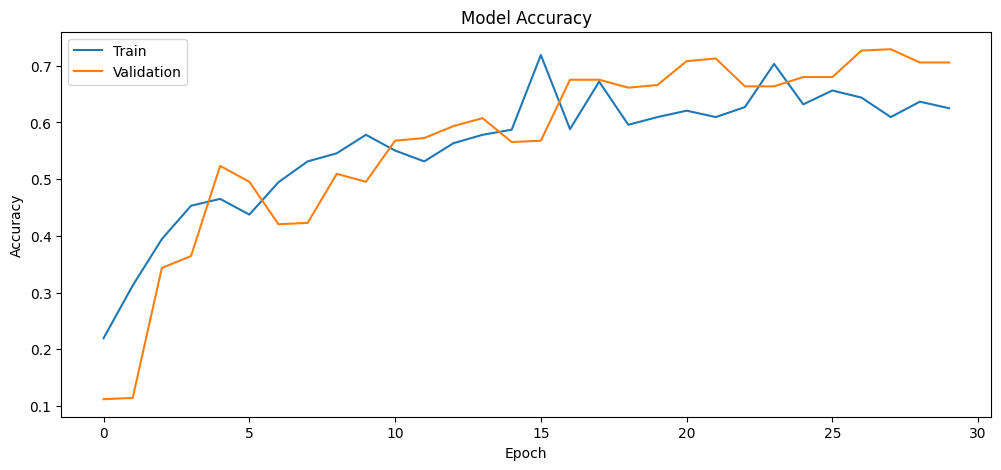

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

**Evaluate the model on test data**

In [ ]:
accuracy = model2.evaluate(X_test_normalized, y_test_encoded, verbose=2)

15/15 - 1s - 37ms/step - accuracy: 0.7116 - loss: 0.9382


**Plotting the Confusion Matrix**

In [ ]:
# Here we would get the output as probablities for each category
y_pred=model2.predict(X_test_normalized)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


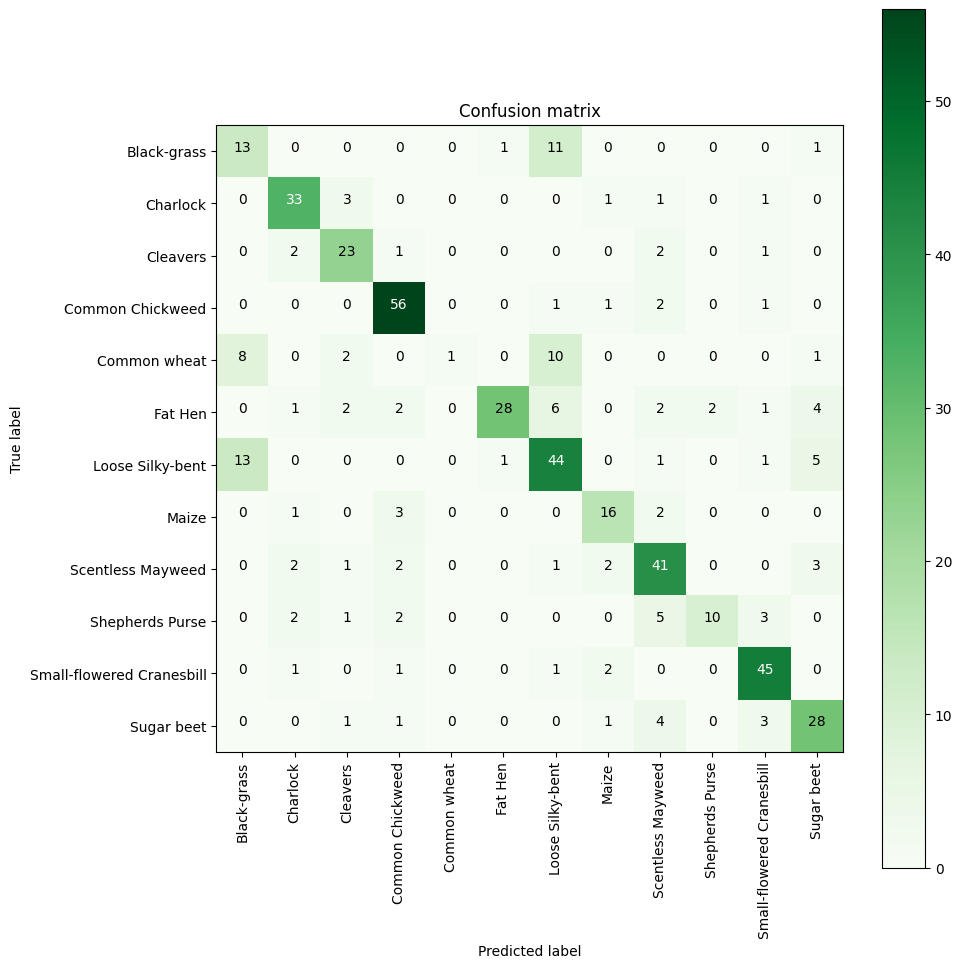

In [ ]:
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Greens):

    fig = plt.figure(figsize=(10,10))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Predict the values from the validation dataset
predY = model2.predict(X_test_normalized)
predYClasses = np.argmax(predY, axis = 1)
trueY = np.argmax(y_test_encoded, axis = 1)

# confusion matrix
confusionMTX = confusion_matrix(trueY, predYClasses)

# plot the confusion matrix
plot_confusion_matrix(confusionMTX, classes = list(enc.classes_))

**Plotting Classification Report**

In [ ]:
# Plotting the classification report
cr=classification_report(trueY,predYClasses)
print(cr)

              precision    recall  f1-score   support

           0       0.38      0.50      0.43        26
           1       0.79      0.85      0.81        39
           2       0.70      0.79      0.74        29
           3       0.82      0.92      0.87        61
           4       1.00      0.05      0.09        22
           5       0.93      0.58      0.72        48
           6       0.59      0.68      0.63        65
           7       0.70      0.73      0.71        22
           8       0.68      0.79      0.73        52
           9       0.83      0.43      0.57        23
          10       0.80      0.90      0.85        50
          11       0.67      0.74      0.70        38

    accuracy                           0.71       475
   macro avg       0.74      0.66      0.66       475
weighted avg       0.74      0.71      0.70       475



## Final Model

Comment on the final model you have selected and use the same in the below code to visualize the image.

**Key Observations**

**Overall Accuracy:**
Model 1: 71%
Model 2: 72%
Model 2 shows a slight improvement in overall accuracy compared to Model 1.

**Macro Average F1-Score:**
Model 1: 0.62
Model 2: 0.64
Model 2 also has a slightly better macro-average F1-score, indicating that it performs better across all classes when considering precision and recall.

**Class-wise Comparison:**

Black-grass (Class 0):

Model 1: Precision: 0.00, Recall: 0.00, F1-score: 0.00

Model 2: Precision: 0.30, Recall: 0.23, F1-score: 0.26

Improvement: Model 2 shows significant improvement, even though performance is still low. Black-grass remains difficult to classify.
Charlock (Class 1):

Model 1: Precision: 0.72, Recall: 0.79, F1-score: 0.76
Model 2: Precision: 0.84, Recall: 0.82, F1-score: 0.83
Improvement: Model 2 has improved in both precision and recall.

**Cleavers (Class 2):**

Model 1: Precision: 0.67, Recall: 0.41, F1-score: 0.51
Model 2: Precision: 0.71, Recall: 0.83, F1-score: 0.76

Improvement: Model 2 shows a significant improvement in recall and overall performance.

**Common Chickweed (Class 3):**

Model 1: Precision: 0.80, Recall: 0.92, F1-score: 0.85
Model 2: Precision: 0.88, Recall: 0.95, F1-score: 0.91

Improvement: Model 2 improves in both precision and recall.

**Common Wheat (Class 4):**

Model 1: Precision: 0.33, Recall: 0.14, F1-score: 0.19
Model 2: Precision: 0.00, Recall: 0.00, F1-score: 0.00

Decline: Model 2 performs worse for this class, with no correct classifications.

**Fat Hen (Class 5):**

Model 1: Precision: 0.66, Recall: 0.81, F1-score: 0.73
Model 2: Precision: 0.92, Recall: 0.69, F1-score: 0.79

Mixed: Model 2 improves in precision but has a lower recall than Model 1.

**Loose Silky-bent (Class 6):**

Model 1: Precision: 0.58, Recall: 0.95, F1-score: 0.73
Model 2: Precision: 0.56, Recall: 0.75, F1-score: 0.64

Decline: Model 2 has a drop in recall, leading to a decrease in the F1-score.

**Maize (Class 7):**

Model 1: Precision: 0.78, Recall: 0.64, F1-score: 0.70
Model 2: Precision: 0.75, Recall: 0.68, F1-score: 0.71

Slight Improvement: Model 2 shows slight improvements.

**Scentless Mayweed (Class 8):**

Model 1: Precision: 0.68, Recall: 0.73, F1-score: 0.70
Model 2: Precision: 0.72, Recall: 0.79, F1-score: 0.75

Improvement: Model 2 performs better.

**Shepherds Purse (Class 9):**

Model 1: Precision: 0.86, Recall: 0.52, F1-score: 0.65
Model 2: Precision: 0.78, Recall: 0.30, F1-score: 0.44

Decline: Model 2 shows a drop in recall and overall performance.

**Small-flowered Cranesbill (Class 10):**

Model 1: Precision: 0.98, Recall: 0.88, F1-score: 0.93
Model 2: Precision: 0.79, Recall: 0.88, F1-score: 0.83

Slight Decline: Model 2 has slightly lower precision and F1-score.

**Sugar Beet (Class 11):**

Model 1: Precision: 0.76, Recall: 0.74, F1-score: 0.75
Model 2: Precision: 0.65, Recall: 0.87, F1-score: 0.74

Mixed: Model 2 improves recall but reduces precision slightly.

**Summary:**

Model 2 performs slightly better overall, with improvements in accuracy, macro average, and weighted average.

Some classes, like Cleavers, Charlock, and Common Chickweed, saw significant improvements in Model 2.

However, Model 2 shows declines in certain classes like Loose Silky-bent, Shepherds Purse, and Common Wheat.

### Visualizing the prediction

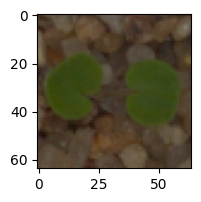

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Predicted Label ['Small-flowered Cranesbill']
True Label Small-flowered Cranesbill


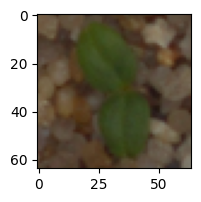

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Predicted Label ['Cleavers']
True Label Cleavers


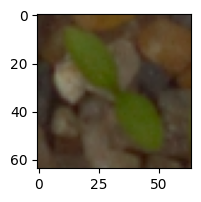

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Predicted Label ['Common Chickweed']
True Label Common Chickweed


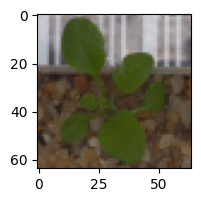

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Predicted Label ['Small-flowered Cranesbill']
True Label Shepherds Purse


In [ ]:

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_test[2])
plt.show()
## Complete the code to predict the test data using the final model selected
print('Predicted Label', enc.inverse_transform(model2.predict((X_test_normalized[2].reshape(1,64,64,3)))))   # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_encoded)[2])                                               # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_test[33])
plt.show()
## Complete the code to predict the test data using the final model selected
print('Predicted Label', enc.inverse_transform(model2.predict((X_test_normalized[33].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_encoded)[33])                                              # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_test[59],)
plt.show()
## Complete the code to predict the test data using the final model selected
print('Predicted Label', enc.inverse_transform(model2.predict((X_test_normalized[59].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_encoded)[59])                                              # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_test[36])
plt.show()
## Complete the code to predict the test data using the final model selected
print('Predicted Label', enc.inverse_transform(model2.predict((X_test_normalized[36].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_encoded)[36])                                              # using inverse_transform() to get the output label from the output vector

## Actionable Insights and Business Recommendations

**Data Augmentation Boosts Performance:**

Model 2 (with augmentation) has improved accuracy (72% vs 71%) and better class-specific precision and recall, especially for Cleavers (Class 2) and Common Chickweed (Class 3).

**Class-Specific Impact:**

Data augmentation significantly improved Cleavers (Class 2), Loose Silky-bent (Class 6), and Sugar Beet (Class 11), increasing both precision and recall.

**Challenges Remain for Certain Classes:**

Despite augmentation, Black-grass (Class 0) and Common Wheat (Class 4) still perform poorly. Augmentation alone might not be enough for these classes.

**Recommendations:**

**Combine Augmentation with Class Balancing:** For classes like Black-grass, try oversampling or class weighting in addition to augmentation.

**Refine Data Augmentation:** Focus on applying class-specific augmentations that better capture the unique characteristics of underperforming classes.

**Ensemble Approach:** Combine models with and without augmentation to improve generalization across all classes.

_____